In [45]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
 



In [46]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [47]:
data = df.drop(columns='Time')
data

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [48]:
from matplotlib import rcParams

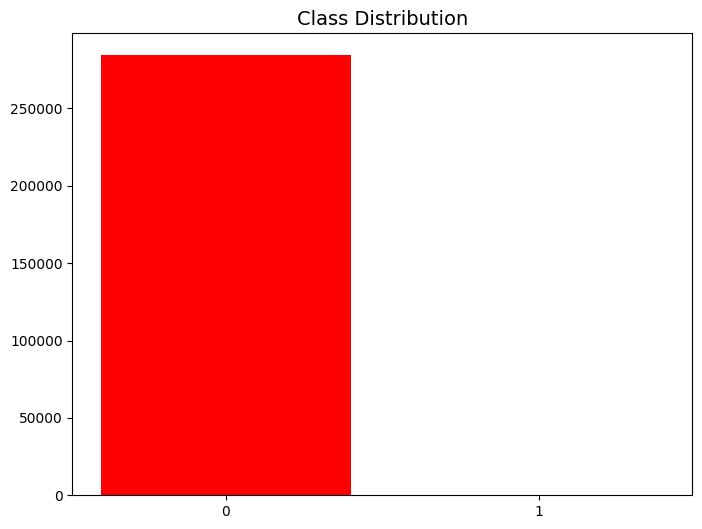

In [49]:
rcParams['figure.figsize'] = 8, 6
plt.bar(data['Class'].unique(), data['Class'].value_counts(), color=['red', 'green'])
plt.xticks([0, 1])
plt.title("Class Distribution", fontsize=14)
plt.show()

In [50]:
x = data.drop('Class', axis=1)
y = data['Class']

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [52]:
Hp_prams = {'criterion': ['gini', 'entropy'],
            'max_depth':[1, 2, 3, 4, 5, 10, 15, 20]}
tree_Gs_param = GridSearchCV(DecisionTreeClassifier(), Hp_prams, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
tree_Gs_param.fit(x_train, y_train)
print('The best parameter combined is .......')
print(tree_Gs_param.best_params_)
print('The best score is .......')
print(tree_Gs_param.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
The best parameter combined is .......
{'criterion': 'entropy', 'max_depth': 4}
The best score is .......
0.939590627457507


In [53]:
y_pred = tree_Gs_param.predict(x_test)

In [54]:
cm1 = confusion_matrix(y_test, y_pred)

print(cm1)

print(classification_report(y_test, y_pred, target_names=["Safe", "Fraud"]))
 
#Calculate sensitivity and specificity
 
total1=sum(sum(cm1))

accuracy1=(cm1[0,0]+cm1[1,1])/total1

print ('Accuracy : ', accuracy1)
 
sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])

print('Sensitivity : ', sensitivity1 )
 
specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])

print('Specificity : ', specificity1)
 

[[56852    12]
 [   19    79]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56864
       Fraud       0.87      0.81      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.9994557775359011
Sensitivity :  0.9997889701744513
Specificity :  0.8061224489795918


In [55]:
from sklearn.tree import export_graphviz
from sklearn import tree
import graphviz
import pydotplus
from IPython.display import Image

In [57]:
from sklearn.tree import export_graphviz
import graphviz
 
best_model = tree_Gs_param.best_estimator_
 
dot_data = export_graphviz(
    best_model,
    out_file=None,
    feature_names=x_train.columns,
    class_names=["Good", "Fraud"],
    filled=True,
    rounded=True
)
 
graph = graphviz.Source(dot_data)
graph
 

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [58]:
dot_data = tree.export_graphviz(tree_Gs_param, out_file=None,
                                class_names=["Safe", "Fraud"])
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

AttributeError: 'GridSearchCV' object has no attribute 'tree_'

In [61]:
from sklearn.ensemble import BaggingClassifier
hp_bagging = {'n_estimators':[3,4,5,6]}
Tree_Gridsearch_paramters=GridSearchCV(BaggingClassifier(),hp_bagging,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
tree_bagg = Tree_Gridsearch_paramters.fit(x_train, y_train)


#Print the best hyper paramters combination for the best model
print ("The best paramter combination is ")
print(tree_bagg.best_params_)  #gets best estimator
Final_Model=tree_bagg.best_estimator_ #gets best estimator
print("The best AUC score was ")
print(tree_bagg.best_score_)  #gets best score for best estimator # -0.83828599184062269


Fitting 5 folds for each of 4 candidates, totalling 20 fits
The best paramter combination is 
{'n_estimators': 6}
The best AUC score was 
0.9198817501742502


In [62]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
hp_RF = {'n_estimators':[3,4,5,6]}



Tree_Gridsearch_paramters=GridSearchCV(BaggingClassifier(),hp_bagging,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
tree_bagg = Tree_Gridsearch_paramters.fit(x_train, y_train)


#Print the best hyper paramters combination for the best model
print ("The best paramter combination is ")
print(tree_bagg.best_params_)  #gets best estimator
Final_Model=tree_bagg.best_estimator_ #gets best estimator
print("The best AUC score was ")
print(tree_bagg.best_score_)  #gets best score for best estimator # -0.83828599184062269


Fitting 5 folds for each of 4 candidates, totalling 20 fits
The best paramter combination is 
{'n_estimators': 6}
The best AUC score was 
0.9185767197271282
